# Calcul de l'Indice de Qualite Economique (IQE) des parcelles agricoles
# SCOT Rhone Provence Baronnies

Ce notebook calcule l'IQE pour chaque parcelle agricole du territoire du SCOT RPB.

**Structure du notebook :**
1. Chargement et preparation des donnees RPG
2. Correction des codes INSEE par jointure spatiale
3. Jointure avec les donnees PBS et calcul de l'IQE
4. Statistiques descriptives
5. Cartographie interactive

**Sources :**
- RPG 2023 (IGN)
- Coefficients PBS 2020 (Agreste)
- Grille de classification IQE (CGAAER 2020)

---
## 1. Chargement et preparation des donnees RPG

In [1]:
# =============================================================================
# 1.1 IMPORT DES LIBRAIRIES
# =============================================================================

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

In [2]:
# =============================================================================
# 1.2 CHARGEMENT DU RPG
# =============================================================================
# Le Registre Parcellaire Graphique (RPG) contient les parcelles agricoles
# declarees dans le cadre de la PAC.
# Source : IGN (https://geoservices.ign.fr/rpg)

print("Chargement du RPG...")
rpg = gpd.read_file('RPG_pac_RPB.gpkg')

print(f"Nombre de parcelles : {len(rpg):,}")
print(f"Colonnes disponibles : {rpg.columns.tolist()}")

Chargement du RPG...
Nombre de parcelles : 65,067
Colonnes disponibles : ['code_culture', 'code_group', 'surf_parc', 'culture_d1', 'culture_d2', 'cat_cult_p', 'layer', 'path', 'insee', 'nom', 'wikipedia', 'surf_ha', 'DEMO_INSEE', 'DEMO_INS_1', 'DEMO_INS_2', 'DEMO_INS_3', 'DEMO_INS_4', 'DEMO_INS_5', 'DEMO_INS_6', 'DEMO_INS_7', 'DEMO_INS_8', 'DEMO_INS_9', 'DEMO_INS10', 'DEMO_INS11', 'DEMO_INS12', 'DEMO_INS13', 'DEMO_INS14', 'DEMO_INS15', 'DEMO_INS16', 'DEMO_INS17', 'geometry']


In [3]:
# =============================================================================
# 1.3 VERIFICATION ET REPROJECTION EN LAMBERT 93
# =============================================================================
# Le systeme de coordonnees Lambert 93 (EPSG:2154) est la projection officielle
# francaise en metres. Elle est indispensable pour un calcul de surface correct.

if rpg.crs is None or rpg.crs.to_epsg() != 2154:
    print(f"Systeme actuel : {rpg.crs}. Reprojection en Lambert 93...")
    rpg = rpg.to_crs(epsg=2154)
else:
    print("Donnees deja en Lambert 93 (EPSG:2154)")

# Recalcul de la surface a partir de la geometrie
# rpg.geometry.area retourne la surface en m2 (Lambert 93 est en metres)
rpg['surf_ha_calculee'] = rpg.geometry.area / 10000

print(f"Surface totale calculee : {rpg['surf_ha_calculee'].sum():,.1f} ha")

Systeme actuel : EPSG:3057. Reprojection en Lambert 93...
Surface totale calculee : 98,516.5 ha


---
## 2. Correction des codes INSEE par jointure spatiale

In [4]:
# =============================================================================
# 2.1 CHARGEMENT DES COMMUNES (ADMIN EXPRESS)
# =============================================================================
# Les donnees ADMIN EXPRESS de l'IGN contiennent les limites communales
# avec les codes INSEE officiels.
# Source : IGN (https://geoservices.ign.fr/adminexpress)

print("Chargement des communes ADMIN EXPRESS...")
communes = gpd.read_file('ADE_4-0_GPKG_LAMB93_FXX-ED2026-02-16.gpkg', layer='commune')
communes = communes.to_crs(epsg=2154)

print(f"Nombre de communes : {len(communes):,}")

Chargement des communes ADMIN EXPRESS...
Nombre de communes : 34,746


In [5]:
# =============================================================================
# 2.2 JOINTURE SPATIALE PARCELLES / COMMUNES
# =============================================================================
# On attribue a chaque parcelle le code INSEE de la commune dans laquelle
# se trouve son centroide. Cette methode corrige les eventuelles erreurs
# de code INSEE dans les donnees RPG d'origine.

print("Jointure spatiale en cours...")

# Calcul du centroide de chaque parcelle
rpg_centroides = rpg.copy()
rpg_centroides['geometry'] = rpg_centroides.geometry.centroid

# Jointure spatiale : on recupere le code INSEE de la commune contenant le centroide
rpg_corrige = gpd.sjoin(
    rpg_centroides,
    communes[['code_insee', 'nom_officiel', 'code_insee_de_la_region', 'geometry']],
    how='left',
    predicate='within'
)

# Restauration de la geometrie originale (polygones)
rpg_corrige['geometry'] = rpg.geometry.values

# Renommage des colonnes pour plus de clarte
rpg_corrige = rpg_corrige.rename(columns={
    'code_insee': 'INSEE_CORRIGE',
    'nom_officiel': 'NOM_COMMUNE_CORRIGE',
    'code_insee_de_la_region': 'CODE_REGION'
})

# Extraction du code departement (2 premiers caracteres du code INSEE)
rpg_corrige['code_dep'] = rpg_corrige['INSEE_CORRIGE'].str[:2]

# Attribution du nom du departement
dict_dep = {'07': 'Ardeche', '26': 'Drome', '84': 'Vaucluse'}
rpg_corrige['nom_dep'] = rpg_corrige['code_dep'].map(dict_dep).fillna('Autre')

print(f"Jointure terminee : {len(rpg_corrige):,} parcelles")
print(f"\nRepartition par departement :")
print(rpg_corrige['nom_dep'].value_counts())

Jointure spatiale en cours...
Jointure terminee : 65,067 parcelles

Repartition par departement :
nom_dep
Drome       48539
Ardeche      8958
Vaucluse     7544
Autre          26
Name: count, dtype: int64


---
## 3. Jointure avec les donnees PBS et calcul de l'IQE

In [6]:
# =============================================================================
# 3.1 CHARGEMENT DU DICTIONNAIRE DE CORRESPONDANCE RPG -> PBS
# =============================================================================
# Le dictionnaire etablit la correspondance entre les codes culture RPG
# et les coefficients de Production Brute Standard (PBS) par region.
# Source : Agreste (https://agreste.agriculture.gouv.fr)

print("Chargement du dictionnaire RPG -> PBS...")
dico = pd.read_csv('DICTIONNAIRE_RPG_CPS_SCOT_RPB.csv', sep=';')

# Creation des dictionnaires de lookup par region
dico_pbs_ra = dict(zip(dico['CODE_RPG'], dico['PBS_RHONE_ALPES']))
dico_pbs_paca = dict(zip(dico['CODE_RPG'], dico['PBS_PACA']))

print(f"Codes dans le dictionnaire : {len(dico)}")
print(f"PBS moyenne Rhone-Alpes : {dico['PBS_RHONE_ALPES'].mean():,.0f} euros/ha")
print(f"PBS moyenne PACA : {dico['PBS_PACA'].mean():,.0f} euros/ha")

Chargement du dictionnaire RPG -> PBS...
Codes dans le dictionnaire : 110
PBS moyenne Rhone-Alpes : 9,441 euros/ha
PBS moyenne PACA : 12,159 euros/ha


In [7]:
# =============================================================================
# 3.2 ATTRIBUTION DE LA PBS SELON LE DEPARTEMENT
# =============================================================================
# Le territoire du SCOT RPB est a cheval sur deux regions PBS :
# - Ardeche (07) et Drome (26) : coefficients Rhone-Alpes
# - Vaucluse (84) : coefficients PACA

DEP_REGION = {'07': 'RA', '26': 'RA', '84': 'PACA'}

def get_pbs(row):
    """Retourne la PBS en euros/ha selon la culture et le departement."""
    code = row['code_culture']
    code_dep = str(row['code_dep'])
    region = DEP_REGION.get(code_dep, 'RA')
    if region == 'RA':
        return dico_pbs_ra.get(code, 0.0)
    else:
        return dico_pbs_paca.get(code, 0.0)

# Application de la fonction a chaque parcelle
rpg_corrige['PBS_HA'] = rpg_corrige.apply(get_pbs, axis=1)

# Calcul de la PBS totale de la parcelle (PBS/ha x surface)
rpg_corrige['PBS_TOTALE'] = rpg_corrige['PBS_HA'] * rpg_corrige['surf_ha_calculee']

print(f"PBS attribuee a {len(rpg_corrige):,} parcelles")

PBS attribuee a 65,067 parcelles


In [8]:
# =============================================================================
# 3.3 CALCUL DE L'IQE NORMALISE (0 A 1)
# =============================================================================
# L'IQE normalise permet de comparer les parcelles sur une echelle commune.
# Formule : IQE = (PBS - PBS_min) / (PBS_max - PBS_min)

pbs_min = rpg_corrige['PBS_HA'].min()
pbs_max = rpg_corrige['PBS_HA'].max()

rpg_corrige['IQE_NORMALISE'] = (rpg_corrige['PBS_HA'] - pbs_min) / (pbs_max - pbs_min)

print(f"PBS minimum : {pbs_min:,.2f} euros/ha")
print(f"PBS maximum : {pbs_max:,.2f} euros/ha")
print(f"IQE normalise : 0 (faible) a 1 (tres haute valeur)")

PBS minimum : 0.00 euros/ha
PBS maximum : 112,694.40 euros/ha
IQE normalise : 0 (faible) a 1 (tres haute valeur)


In [9]:
# =============================================================================
# 3.4 CALCUL DU SCORE IQE (1 A 5) SELON LA GRILLE CGAAER
# =============================================================================
# La grille CGAAER (2020) definit 5 niveaux de valeur economique :
# Score 5 : >= 15 000 euros/ha (tres haute valeur)
# Score 4 : 8 000 - 14 999 euros/ha (haute valeur)
# Score 3 : 4 000 - 7 999 euros/ha (valeur moyenne)
# Score 2 : 2 000 - 3 999 euros/ha (faible valeur)
# Score 1 : < 2 000 euros/ha (tres faible valeur)

def score_iqe(pbs):
    """Retourne le score IQE (1-5) selon la PBS en euros/ha."""
    if pbs >= 15000:
        return 5
    elif pbs >= 8000:
        return 4
    elif pbs >= 4000:
        return 3
    elif pbs >= 2000:
        return 2
    else:
        return 1

rpg_corrige['SCORE_IQE'] = rpg_corrige['PBS_HA'].apply(score_iqe)

# Libelle du niveau IQE
libelles_iqe = {
    5: 'Tres haute valeur',
    4: 'Haute valeur',
    3: 'Valeur moyenne',
    2: 'Faible valeur',
    1: 'Tres faible valeur'
}
rpg_corrige['NIVEAU_IQE'] = rpg_corrige['SCORE_IQE'].map(libelles_iqe)

print("Calcul de l'IQE termine")
print(f"\nRepartition des scores IQE :")
print(rpg_corrige['SCORE_IQE'].value_counts().sort_index())

Calcul de l'IQE termine

Repartition des scores IQE :
SCORE_IQE
1    33533
2     7374
3     4543
4    17332
5     2285
Name: count, dtype: int64


---
## 4. Statistiques descriptives

In [10]:
# =============================================================================
# 4.1 RESUME GLOBAL DU TERRITOIRE
# =============================================================================

print("=" * 60)
print("STATISTIQUES IQE - SCOT RPB")
print("=" * 60)

print(f"\nNombre total de parcelles : {len(rpg_corrige):,}")
print(f"Surface agricole totale : {rpg_corrige['surf_ha_calculee'].sum():,.1f} ha")
print(f"Surface moyenne par parcelle : {rpg_corrige['surf_ha_calculee'].mean():.2f} ha")

print(f"\nPBS moyenne : {rpg_corrige['PBS_HA'].mean():,.0f} euros/ha")
print(f"PBS mediane : {rpg_corrige['PBS_HA'].median():,.0f} euros/ha")
print(f"PBS totale territoire : {rpg_corrige['PBS_TOTALE'].sum()/1e6:.2f} millions euros")

print(f"\nIQE normalise moyen : {rpg_corrige['IQE_NORMALISE'].mean():.4f}")

STATISTIQUES IQE - SCOT RPB

Nombre total de parcelles : 65,067
Surface agricole totale : 98,516.5 ha
Surface moyenne par parcelle : 1.51 ha

PBS moyenne : 5,142 euros/ha
PBS mediane : 1,567 euros/ha
PBS totale territoire : 400.58 millions euros

IQE normalise moyen : 0.0456


In [11]:
# =============================================================================
# 4.2 DISTRIBUTION DES SCORES IQE
# =============================================================================

print("\nDISTRIBUTION DES SCORES IQE")
print("-" * 60)
print(f"{'Score':<8} {'Niveau':<25} {'Parcelles':>10} {'%':>8} {'Surface (ha)':>15}")
print("-" * 60)

for score in [5, 4, 3, 2, 1]:
    subset = rpg_corrige[rpg_corrige['SCORE_IQE'] == score]
    n = len(subset)
    pct = n / len(rpg_corrige) * 100
    surf = subset['surf_ha_calculee'].sum()
    niveau = libelles_iqe[score]
    print(f"{score:<8} {niveau:<25} {n:>10,} {pct:>7.1f}% {surf:>14,.1f}")


DISTRIBUTION DES SCORES IQE
------------------------------------------------------------
Score    Niveau                     Parcelles        %    Surface (ha)
------------------------------------------------------------
5        Tres haute valeur              2,285     3.5%        2,854.4
4        Haute valeur                  17,332    26.6%       20,673.3
3        Valeur moyenne                 4,543     7.0%        2,160.2
2        Faible valeur                  7,374    11.3%        7,733.7
1        Tres faible valeur            33,533    51.5%       65,095.0


In [12]:
# =============================================================================
# 4.3 STATISTIQUES PAR DEPARTEMENT
# =============================================================================

print("\nSTATISTIQUES PAR DEPARTEMENT")
print("-" * 60)

stats_dep = rpg_corrige.groupby('nom_dep').agg({
    'surf_ha_calculee': 'sum',
    'PBS_HA': 'mean',
    'PBS_TOTALE': 'sum',
    'IQE_NORMALISE': 'mean',
    'code_culture': 'count'
}).round(2)

stats_dep.columns = ['Surface (ha)', 'PBS moy (E/ha)', 'PBS tot (E)', 'IQE moy', 'Nb parcelles']
stats_dep['PBS tot (ME)'] = (stats_dep['PBS tot (E)'] / 1e6).round(2)
stats_dep = stats_dep.drop('PBS tot (E)', axis=1)

print(stats_dep)


STATISTIQUES PAR DEPARTEMENT
------------------------------------------------------------
          Surface (ha)  PBS moy (E/ha)  IQE moy  Nb parcelles  PBS tot (ME)
nom_dep                                                                    
Ardeche       14650.50         5442.25     0.05          8958         48.51
Autre             3.63          253.95     0.00            26          0.00
Drome         71501.79         4632.88     0.04         48539        248.53
Vaucluse      12360.62         8078.15     0.07          7544        103.53


In [13]:
# =============================================================================
# 4.4 TOP 10 CULTURES PAR PBS MOYENNE
# =============================================================================

print("\nTOP 10 CULTURES (PBS moyenne)")
print("-" * 60)

top_cultures = rpg_corrige.groupby('code_culture').agg({
    'PBS_HA': 'mean',
    'surf_ha_calculee': 'sum',
    'code_culture': 'count'
}).rename(columns={'code_culture': 'nb_parcelles'})

top_cultures = top_cultures.sort_values('PBS_HA', ascending=False).head(10)

for code, row in top_cultures.iterrows():
    print(f"{code:5} : {row['PBS_HA']:>10,.0f} E/ha - {row['surf_ha_calculee']:>8,.1f} ha ({int(row['nb_parcelles'])} parcelles)")


TOP 10 CULTURES (PBS moyenne)
------------------------------------------------------------
HPC   :    112,694 E/ha -      3.7 ha (9 parcelles)
CHU   :     37,485 E/ha -      4.3 ha (4 parcelles)
CAR   :     37,169 E/ha -     83.2 ha (18 parcelles)
TBT   :     36,538 E/ha -      2.7 ha (3 parcelles)
POR   :     36,538 E/ha -      3.1 ha (3 parcelles)
MLO   :     35,347 E/ha -    211.9 ha (89 parcelles)
RDI   :     32,752 E/ha -     18.1 ha (6 parcelles)
FRA   :     32,752 E/ha -      5.9 ha (33 parcelles)
FLP   :     32,411 E/ha -     65.1 ha (122 parcelles)
POT   :     32,129 E/ha -    105.3 ha (79 parcelles)


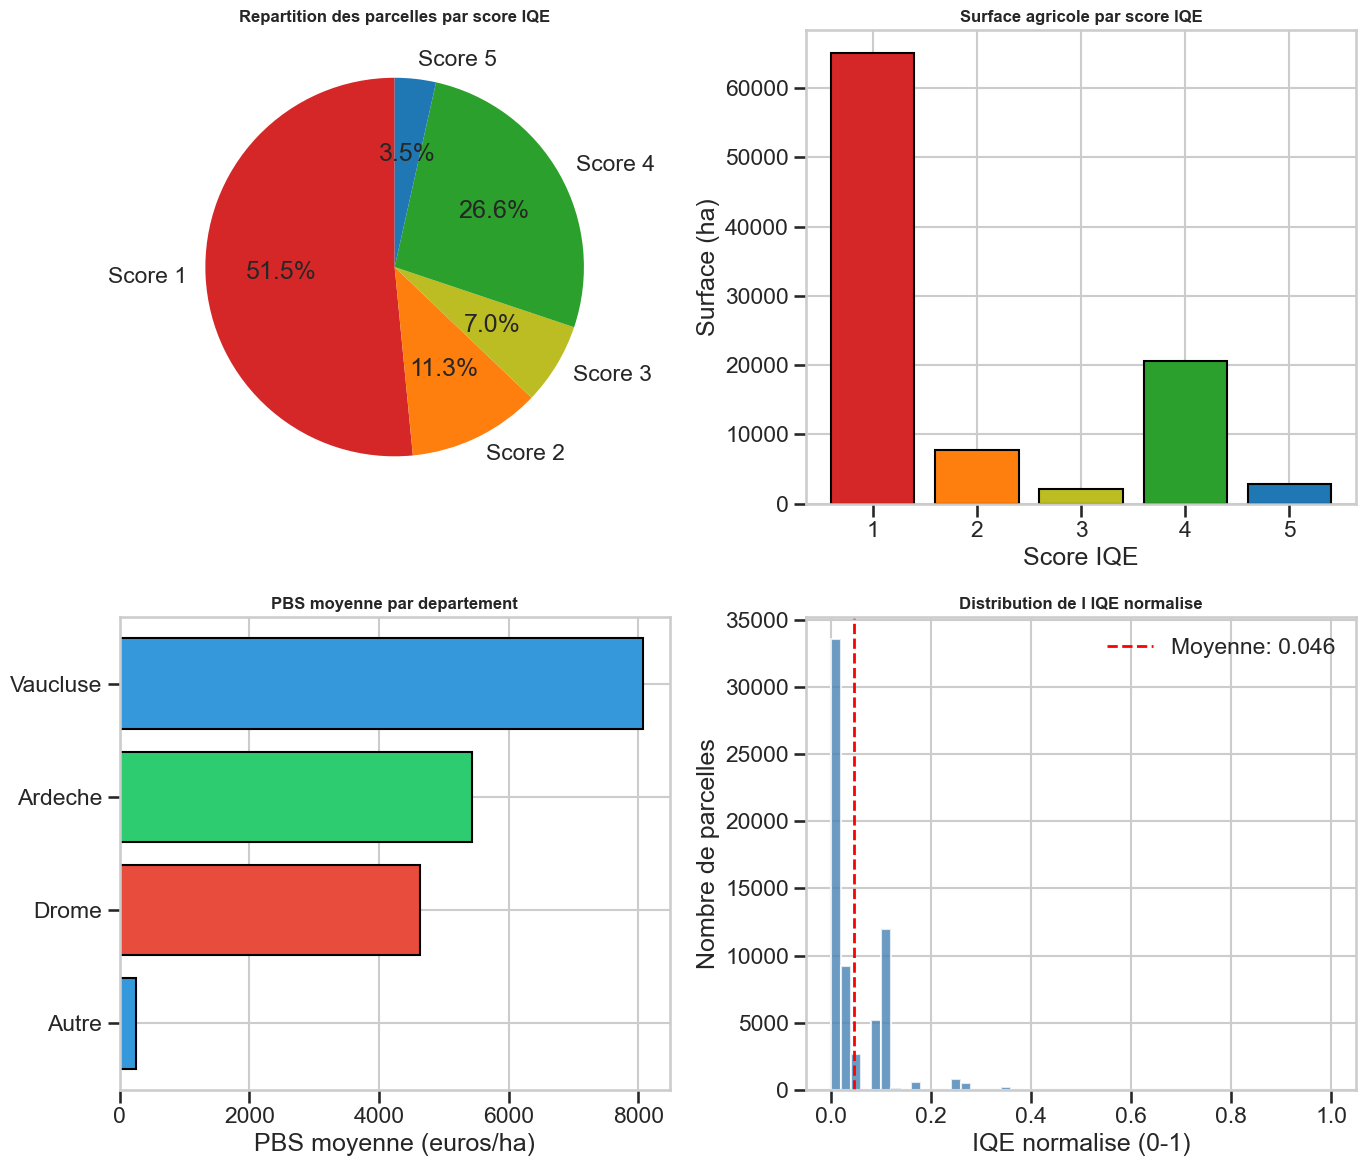

In [14]:
# =============================================================================
# 4.5 GRAPHIQUES DE SYNTHESE
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
colors_iqe = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

# Graphique 1 : Repartition des scores IQE
ax1 = axes[0, 0]
scores_count = rpg_corrige['SCORE_IQE'].value_counts().sort_index()
labels = [f'Score {i}' for i in range(1, 6)]
ax1.pie(scores_count, labels=labels, autopct='%1.1f%%', colors=colors_iqe, startangle=90)
ax1.set_title('Repartition des parcelles par score IQE', fontsize=12, fontweight='bold')

# Graphique 2 : Surface par score IQE
ax2 = axes[0, 1]
surf_score = rpg_corrige.groupby('SCORE_IQE')['surf_ha_calculee'].sum()
bars = ax2.bar(surf_score.index, surf_score.values, color=colors_iqe, edgecolor='black')
ax2.set_xlabel('Score IQE')
ax2.set_ylabel('Surface (ha)')
ax2.set_title('Surface agricole par score IQE', fontsize=12, fontweight='bold')
ax2.set_xticks([1, 2, 3, 4, 5])

# Graphique 3 : PBS moyenne par departement
ax3 = axes[1, 0]
pbs_dep = rpg_corrige.groupby('nom_dep')['PBS_HA'].mean().sort_values(ascending=True)
colors_dep = ['#3498db', '#e74c3c', '#2ecc71']
ax3.barh(pbs_dep.index, pbs_dep.values, color=colors_dep, edgecolor='black')
ax3.set_xlabel('PBS moyenne (euros/ha)')
ax3.set_title('PBS moyenne par departement', fontsize=12, fontweight='bold')

# Graphique 4 : Distribution IQE normalise
ax4 = axes[1, 1]
ax4.hist(rpg_corrige['IQE_NORMALISE'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax4.axvline(rpg_corrige['IQE_NORMALISE'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Moyenne: {rpg_corrige["IQE_NORMALISE"].mean():.3f}')
ax4.set_xlabel('IQE normalise (0-1)')
ax4.set_ylabel('Nombre de parcelles')
ax4.set_title('Distribution de l IQE normalise', fontsize=12, fontweight='bold')
ax4.legend()

plt.tight_layout()
plt.savefig('IQE_synthese.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Cartographie interactive

In [15]:
# =============================================================================
# 5.1 PREPARATION DES DONNEES POUR LA CARTE
# =============================================================================
# On selectionne une commune pour la visualisation (trop de donnees pour tout afficher)

commune_test = 'Montelimar'

if commune_test not in rpg_corrige['NOM_COMMUNE_CORRIGE'].values:
    commune_test = rpg_corrige['NOM_COMMUNE_CORRIGE'].dropna().iloc[0]
    print(f"Commune choisie par defaut : {commune_test}")

rpg_carte = rpg_corrige[rpg_corrige['NOM_COMMUNE_CORRIGE'] == commune_test].copy()
print(f"Parcelles selectionnees : {len(rpg_carte)} ({commune_test})")

# Calcul du centre de la zone
centre_x = rpg_carte.geometry.centroid.x.mean()
centre_y = rpg_carte.geometry.centroid.y.mean()

# Conversion du centre en coordonnees GPS (WGS84)
centre_point = gpd.GeoSeries(
    gpd.points_from_xy([centre_x], [centre_y]),
    crs='EPSG:2154'
).to_crs(epsg=4326)

centre_lat = centre_point.y.iloc[0]
centre_lon = centre_point.x.iloc[0]

print(f"Centre de la carte : {centre_lat:.4f}, {centre_lon:.4f}")

Commune choisie par defaut : Alba-la-Romaine
Parcelles selectionnees : 756 (Alba-la-Romaine)
Centre de la carte : 44.5545, 4.5915


In [16]:
# =============================================================================
# 5.2 REPROJECTION EN WGS84 POUR FOLIUM
# =============================================================================
# Folium necessite des coordonnees en WGS84 (EPSG:4326)

rpg_gps = rpg_carte.to_crs(epsg=4326)

# Arrondi de l'IQE pour l'affichage
rpg_gps['IQE_ARRONDI'] = rpg_gps['IQE_NORMALISE'].round(3)
rpg_gps['PBS_HA_ARRONDI'] = rpg_gps['PBS_HA'].round(0).astype(int)
rpg_gps['SURFACE_ARRONDI'] = rpg_gps['surf_ha_calculee'].round(2)

In [17]:
# =============================================================================
# 5.3 CREATION DE LA CARTE INTERACTIVE
# =============================================================================

# Limites de la France metropolitaine
limites_france = [[41.3, -5.2], [51.1, 9.6]]

# Creation de la carte centree sur la zone d'etude
ma_carte = folium.Map(
    location=[centre_lat, centre_lon],
    zoom_start=13,
    min_zoom=5,
    max_bounds=True,
    bounds=limites_france
)

# Ajout des fonds de carte
folium.TileLayer(
    tiles='https://{s}.tile.openstreetmap.fr/osmfr/{z}/{x}/{y}.png',
    attr='OpenStreetMap France',
    name='OSM France'
).add_to(ma_carte)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery',
    name='Vue Satellite'
).add_to(ma_carte)

print("Carte creee avec succes")

Carte creee avec succes


In [18]:
# =============================================================================
# 5.4 AJOUT DES PARCELLES COLOREES PAR SCORE IQE
# =============================================================================

def couleur_iqe(feature):
    """Retourne le style de la parcelle selon son score IQE."""
    score = feature['properties'].get('SCORE_IQE', 1)
    couleurs = {
        1: '#d62728',  # rouge - tres faible valeur
        2: '#ff7f0e',  # orange - faible valeur
        3: '#bcbd22',  # jaune - valeur moyenne
        4: '#2ca02c',  # vert - haute valeur
        5: '#1f77b4'   # bleu - tres haute valeur
    }
    return {
        'fillColor': couleurs.get(score, '#gray'),
        'color': '#333333',
        'weight': 1,
        'fillOpacity': 0.6
    }

# Ajout des parcelles avec infobulle detaillee
folium.GeoJson(
    rpg_gps,
    name='Parcelles IQE',
    style_function=couleur_iqe,
    tooltip=folium.GeoJsonTooltip(
        fields=['NOM_COMMUNE_CORRIGE', 'code_culture', 'SURFACE_ARRONDI',
                'PBS_HA_ARRONDI', 'SCORE_IQE', 'IQE_ARRONDI'],
        aliases=['Commune:', 'Culture:', 'Surface (ha):',
                 'PBS (E/ha):', 'Score IQE:', 'IQE normalise:'],
        style='background-color: white; color: #333; font-family: arial; font-size: 12px; padding: 10px;'
    )
).add_to(ma_carte)

# Ajout du controle des couches
folium.LayerControl().add_to(ma_carte)

print("Parcelles ajoutees a la carte")

Parcelles ajoutees a la carte


In [19]:
# =============================================================================
# 5.5 AJOUT DE LA LEGENDE
# =============================================================================

legende_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
            background-color: white; padding: 10px; border-radius: 5px;
            border: 2px solid gray; font-family: Arial;">
    <p style="margin: 0 0 5px 0; font-weight: bold;">Score IQE</p>
    <p style="margin: 2px;"><span style="background-color: #1f77b4; padding: 2px 10px;"></span> 5 - Tres haute valeur</p>
    <p style="margin: 2px;"><span style="background-color: #2ca02c; padding: 2px 10px;"></span> 4 - Haute valeur</p>
    <p style="margin: 2px;"><span style="background-color: #bcbd22; padding: 2px 10px;"></span> 3 - Valeur moyenne</p>
    <p style="margin: 2px;"><span style="background-color: #ff7f0e; padding: 2px 10px;"></span> 2 - Faible valeur</p>
    <p style="margin: 2px;"><span style="background-color: #d62728; padding: 2px 10px;"></span> 1 - Tres faible valeur</p>
</div>
'''

ma_carte.get_root().html.add_child(folium.Element(legende_html))

# Affichage de la carte
ma_carte

In [20]:
# =============================================================================
# 5.6 SAUVEGARDE DE LA CARTE EN HTML
# =============================================================================

ma_carte.save('carte_IQE_SCOT_RPB.html')
print("Carte sauvegardee : carte_IQE_SCOT_RPB.html")

Carte sauvegardee : carte_IQE_SCOT_RPB.html


---
## 6. Export des resultats

In [21]:
# =============================================================================
# 6.1 EXPORT DU RPG AVEC IQE EN GEOPACKAGE
# =============================================================================

# Selection des colonnes utiles pour l'export
colonnes_export = [
    'geometry',
    'INSEE_CORRIGE',
    'NOM_COMMUNE_CORRIGE',
    'code_dep',
    'nom_dep',
    'code_culture',
    'surf_ha_calculee',
    'PBS_HA',
    'PBS_TOTALE',
    'IQE_NORMALISE',
    'SCORE_IQE',
    'NIVEAU_IQE'
]

rpg_export = rpg_corrige[colonnes_export].copy()
rpg_export.to_file('RPG_IQE_SCOT_RPB.gpkg', driver='GPKG')

print("Export GeoPackage : RPG_IQE_SCOT_RPB.gpkg")

Export GeoPackage : RPG_IQE_SCOT_RPB.gpkg


In [22]:
# =============================================================================
# 6.2 EXPORT DES STATISTIQUES EN CSV
# =============================================================================

# Statistiques par departement
stats_dep.to_csv('stats_IQE_departements.csv', sep=';')
print("Export CSV : stats_IQE_departements.csv")

# Statistiques par culture
stats_cult = rpg_corrige.groupby('code_culture').agg({
    'surf_ha_calculee': 'sum',
    'PBS_HA': 'mean',
    'PBS_TOTALE': 'sum',
    'IQE_NORMALISE': 'mean',
    'code_culture': 'count'
}).rename(columns={'code_culture': 'nb_parcelles'}).round(2)

stats_cult = stats_cult.sort_values('surf_ha_calculee', ascending=False)
stats_cult.to_csv('stats_IQE_cultures.csv', sep=';')
print("Export CSV : stats_IQE_cultures.csv")

print("\nTraitement termine.")

Export CSV : stats_IQE_departements.csv
Export CSV : stats_IQE_cultures.csv

Traitement termine.
